## Tensor greedy double block extended kaczmarz



In this notebook we experiment the proposed TDGBEK method. The pratical numerical experiments on SuiteSparse matrix is done in another notebook. As well, the experiments on image debluring is done in another notebook.

## 1.  Installation, imports, and utilities

a. Install my tensor toolbox and tensor randomized Kaczmarz algorithms "packages"

a1. Tensor toolbox

In [1]:
%%capture
!pip install -q git+https://github.com/jnlandu/tensor-tensor-toolbox-in-python

a2. randomized Kaczmarz algorithms

In [2]:
%%capture
!pip install -q git+https://github.com/jnlandu/tensor-randomized-kaczmarz-algorithms

b. imports and utilities

In [3]:
## Check if well is installed: it should print the version
import tensor_toolbox
print(tensor_toolbox.__version__())

## Check if well is installed: it should print the version
import trk_algorithms
print(trk_algorithms.__version__())

0.1.0
0.1.0


In [4]:
import torch
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt



#  Imports device abd dtype
#  dtype is set to be torch.float32, meaning that all the tensors are real.
from tensor_toolbox.config import device, DTYPE

# Imports tensor operations: bcirc, t-product, etc.
from tensor_toolbox.tensorLinalg import (
    bcirc,
    t_product,
    t_transpose,
    t_frobenius_norm,
    t_pinv_apply,
    unfold,
    fold
)

#  Imports trk_algorithms utils.
from trk_algorithms.utils import (
    rel_se, make_partitions,
    make_tensor_problem,
    display_results,
    plot_convergence,
)
from trk_algorithms.methods import (
    trek_algorithm,
    trebk_algorithm,
    tregbk_algorithm,
    treabk_algorithm
)

## 2. Tensor greedy double block extended Kaczmarz (TGDBEK)

In [12]:
def tgdbek_algorithm(A, B, T, x_ls, alpha=1.0, eta=0.9, tol=1e-5, rcond=1e-3):
    """
    Tensor greedy double block extended Kaczmarz algorithm.
    It solves the tensor inconsistent system AX=B+eps, where A,
    X, B,and eps are tensors.

    Parameters
    ----------
    A : (m, n, p) tensor.
    B: (m, k, p) tensor.
    T: int. max iterations.
    x_ls: (n, k, p) tensor reference (e.g. least-squares solution).
    eta: greedy threshold. Default .9.
    tol: tolerance. Default 1e-5.
    rcond: relative condition number for torch.linalg.pinv. Default 1e-3.

    Returns:
    --------
    (X_np, iters, res_hist, x_hist_np), runtime
    where X_np is the solution, iters is the number of iterations required to
    exceed the tolerance or  to exceed T, res_hist is the relative error and
    finally runtime is the required running time.

    """
    m, n, p = A.shape
    m_b, k, p_b = B.shape

    # Check dimensional compatibility
    assert (m == m_b) and (p == p_b), "A:(m,n,p), B:(m,k,p) required"

    # Initailize the device and the data type
    device = A.device
    dtype = A.dtype

    #  Initialize
    X = torch.zeros((n, k, p), dtype=dtype, device=device)
    Z = B.clone()

    #  Precompute Frob norm squares of tensor columns  and row slices.
    col_norms_sq = torch.sum(A**2, dim=(0, 2)) + 1e-12               # ||A_{:,j,:}||_F^2 over dims (0,2); shape (n,)
    row_norms_sq = torch.sum(A**2, dim=(1, 2)) + 1e-12               # ||A_{i,:,:}||_F^2 over dims (1,2); shape (m,)

    res_hist = []
    x_hist = []

    res_hist.append(float(rel_se(X, x_ls).item()))
    x_hist.append(X.clone())

    #  Start the loop
    t0 = time.time()
    with torch.no_grad():
        for iter_k in range(T):

            # ========== The Z-step ========:
            trans_A = t_transpose(A)                                 # (n, m, p)
            trans_A_Z = t_product(trans_A, Z)                        # (n, m, p) * (m, k, p) = (n, k, p)
            scores_z = torch.sum(trans_A_Z**2, dim=(1, 2)) / col_norms_sq

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.

            del trans_A                                             # to free memory
            del trans_A_Z                                           # to free memory

            eps_z = eta * torch.max(scores_z)
            U_k = torch.where(scores_z >= eps_z)[0]

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del eps_z
            del scores_z


            #  Block projection and update:
            A_U = A[:, U_k, :]                           # (m, |U|, p)
            W = t_pinv_apply(A_U, Z, rcond=rcond)        # (|U|, k, p) = (A_U)^dagger * Z
            Z = Z - alpha * t_product(A_U, W)            # (m, k, p)

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del W, A_U, U_k

            # =========================================================
            # X-step: corrected greedy set J_k (row-wise residual!)
            # =========================================================
            AX = t_product(A, X)                        # (m, k, p)
            R = B - Z - AX                              # (m, k, p)

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del AX

            scores_x = torch.sum(R**2, dim=(1, 2)) / row_norms_sq
            eps_x = eta * torch.max(scores_x)
            J_k = torch.where(scores_x >= eps_x)[0]

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.

            del R, scores_x, eps_x


            # Block projection and update
            A_J = A[J_k, :, :]                                             # (|J|, n, p)
            rhs = B[J_k, :, :] - Z[J_k, :, :] - t_product(A_J, X)          # (|J|, k, p)
            dX = t_pinv_apply(A_J, rhs, rcond=rcond)                       # (n, k, p)
            X = X + alpha *  dX

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del A_J, rhs, dX

            #============ RSE and tolerance ======
            rse = rel_se(X, x_ls)
            res_hist.append(float(rse))
            x_hist.append(X.clone())

            if rse < tol:
                break

    runtime = time.time() - t0

    return (
        X.detach().cpu().numpy(),
        iter_k + 1,
        np.array(res_hist),
        np.array([x.detach().cpu().numpy() for x in x_hist])
    ), runtime


## 3. Experiments

We test the method in Sec 2. above in simulated systems $A * X = B$, where $B= B+ɛ$.

- We construct $A$, $B$, and $X$, and we try to recover $X$ that satisfies the system.

- We call IT the required iterations to exceed the tolerance or the iter. And CPU the required running time.

### 3.1. Effects of $\eta$ on  the   IT and CPU.

For this case, we consider an overdetermined system.

In [13]:
#  Create a problem:

m, n, p, q = 500, 20,10, 10
# m, n, p, q = 250,50, 50, 50# for A (m, n, p), B(m, q, p)
noise = 0.01
dtype = torch.float32
eta = 0.6
max_iter = 2000
tol = 1e-6

A, X_ls, B = make_tensor_problem(m=m, n=n, p=p, q=q, noise=noise)
print(f"Tensor dimensions: A: {A.shape}, B: {B.shape}, X: {X_ls.shape}")

Tensor dimensions: A: torch.Size([500, 20, 10]), B: torch.Size([500, 10, 10]), X: torch.Size([20, 10, 10])


In [16]:
num_runs = 20
eta_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

avg_hist = np.zeros((len(eta_values), max_iter + 1))    # Changed max_iter to max_iter + 1
avg_time = np.zeros(len(eta_values))
avg_iters = np.zeros(len(eta_values))

plt.figure()
for a_idx, eta in enumerate(eta_values):
    # print(f"Running for eta - {eta}")
    for trial in range(num_runs):
        # print(f"  Trial {trial}")
        (X_tgdbek, k_tgdbek_f, hist_tgdbek, x_hist_tgdbek), t_tgdbek = tgdbek_algorithm(A, B,T=max_iter, x_ls=X_ls, eta=eta, tol=tol)


        avg_hist[a_idx, :len(hist_tgdbek)] += hist_tgdbek
        avg_time[a_idx] += t_tgdbek
        avg_iters[a_idx] += k_tgdbek_f
    # average over runs
    avg_hist[a_idx, :] /= num_runs
    avg_time[a_idx] /= num_runs
    avg_iters[a_idx] /= num_runs
    plt.semilogy(np.arange(len(avg_hist[a_idx, :])), avg_hist[a_idx, :], label=f"tgdbek-{eta}")


plt.xlabel("Iteration")
plt.ylabel("RSE")
plt.legend()
plt.show()

## Plot average CPU time vs eta in a separate figure
plt.figure()
plt.plot(eta_values, avg_time.tolist(), marker='o')
plt.xlabel("eta")
plt.ylabel("CPU Time (s)")
plt.show()

## Print numerical table for paper verification
print(f"{'eta':>5}  {'IT':>6}  {'CPU (s)':>9}")
print("-" * 26)
for eta_v, it, cpu in zip(eta_values, avg_iters.tolist(), avg_time.tolist()):
    print(f"{eta_v:>5.1f}  {it:>6.1f}  {cpu:>9.3f}")


  eta=0.1 ...
  eta=0.2 ...
  eta=0.3 ...
  eta=0.4 ...
  eta=0.5 ...
  eta=0.6 ...
  eta=0.7 ...
  eta=0.8 ...
  eta=0.9 ...
  eta=1.0 ...

  eta      IT    CPU (s)
--------------------------
  0.1     1.0      0.039
  0.2     1.0      0.026
  0.3     1.0      0.026
  0.4     1.0      0.027
  0.5     1.0      0.028
  0.6    31.0      1.255
  0.7    43.0      1.578
  0.8    63.0      1.933
  0.9    97.0      2.518
  1.0   363.0      7.953


### 3.2. Experiments on a random tensor system.

In [53]:
# Create test problem
m, n, p, q = 500, 20,10, 10
# m, n, p, q = 250,50, 50, 50# for A (m, n, p), B(m, q, p)
noise = 0.01
dtype = torch.float32
eta = 0.6
max_iter = 2000
tol = 1e-6

A, X_ls, B = make_tensor_problem(m=m, n=n, p=p, q=q, noise=noise)
print(f"Tensor dimensions: A: {A.shape}, B: {B.shape}, X: {X_ls.shape}")


Tensor dimensions: A: torch.Size([500, 20, 10]), B: torch.Size([500, 10, 10]), X: torch.Size([20, 10, 10])


In [48]:

# Partitions
#  1. Partitions for TREBK. It requires both row and col partitions. # In the paper, they used
#  Sequential generations with s= number of partitions, and tau = their size.

row_partitions_trebk = make_partitions(m,  tau=10, sequential=True)
col_partitions_trebk = make_partitions(n, tau=10, sequential=True)

#  2. Partitions for TREGBK. It only requires partitioning the rows in s blocks
row_partitions_tregbk = make_partitions(m, tau=10, sequential=True)

#  3. Partitions for TREABK:  The same block partitions style as 1.
row_partitions_treabk = make_partitions(m, tau=10, sequential=True)
col_partitions_treabk = make_partitions(n, tau=10, sequential=True)

print(f"Row and col  partitions TREBK: {(len(row_partitions_treabk), len(col_partitions_trebk))}")
print(f"Row and col  partitions TREGBK: {(len(row_partitions_tregbk), "_ ")}")
print(f"Row and col  partitions TREABK: {(len(row_partitions_treabk), len(col_partitions_treabk))}")

Row and col  partitions TREBK: (50, 2)
Row and col  partitions TREGBK: (50, '_ ')
Row and col  partitions TREABK: (50, 2)


In [50]:
# Run  the experiments

(X_trek, k_trek, hist_trek, x_hist_trek), t_trek = trek_algorithm(A, B, x_ls=X_ls, T=max_iter, tol=tol)


(X_trebk, k_trebk, hist_trebk, x_hist_trebk), t_trebk = trebk_algorithm(A, B,x_ls =X_ls, T=max_iter, tol=tol,\
                                              row_partitions=row_partitions_trebk, col_partitions=col_partitions_trebk)

(X_tregbk, k_tregbk, hist_tregbk, x_hist_tregbk), t_tregbk  = tregbk_algorithm(A, B,x_ls =X_ls, T=max_iter, delta=0.7, tol=tol, \
                                              row_partitions=row_partitions_tregbk)

(X_treabk, k_treabk, hist_treabk, x_hist_treabk), t_treabk = treabk_algorithm(A, B,x_ls =X_ls, T=max_iter, alpha=12.0, tol=tol,\
                                        row_partitions=row_partitions_treabk)

(X_tgdbek, k_tgdbek, hist_tgdbek, x_hist_tgdbek), t_tgdbek = tgdbek_algorithm(A, B,T=max_iter, x_ls=X_ls, eta=eta, tol=tol)


In [51]:
results = [
    {'name': 'TREK', 'time': t_trek, 'final_residual': hist_trek[-1], 'iterations': k_trek},
    {'name': 'TREBK', 'time': t_trebk, 'final_residual': hist_trebk[-1], 'iterations': k_trebk},
    {'name': 'TREGBK', 'time': t_tregbk, 'final_residual': hist_tregbk[-1], 'iterations': k_tregbk},
    {'name': 'TREABK', 'time': t_treabk, 'final_residual': hist_treabk[-1], 'iterations': k_treabk},
    {'name': 'TGDBEK', 'time': t_tgdbek, 'final_residual': hist_tgdbek[-1], 'iterations': k_tgdbek},
  ]

display_results(results)

BENCHMARK RESULTS - TENSOR KACZMARZ METHODS (Using T-Product)
Method  Time (s)  Final Relative Residual  Iterations
  TREK  1.251106             9.924012e-07         653
 TREBK  0.937951             8.699141e-07          43
TREGBK  0.719645             9.187955e-07          46
TREABK  0.613521             9.241348e-07         315
TGDBEK  0.637748             6.237389e-07          32


,Method,Time (s),Final Relative Residual,Iterations
0,TREK,1.251106,9.924012e-07,653
1,TREBK,0.937951,8.699141e-07,43
2,TREGBK,0.719645,9.187955e-07,46
3,TREABK,0.613521,9.241348e-07,315
4,TGDBEK,0.637748,6.237389e-07,32


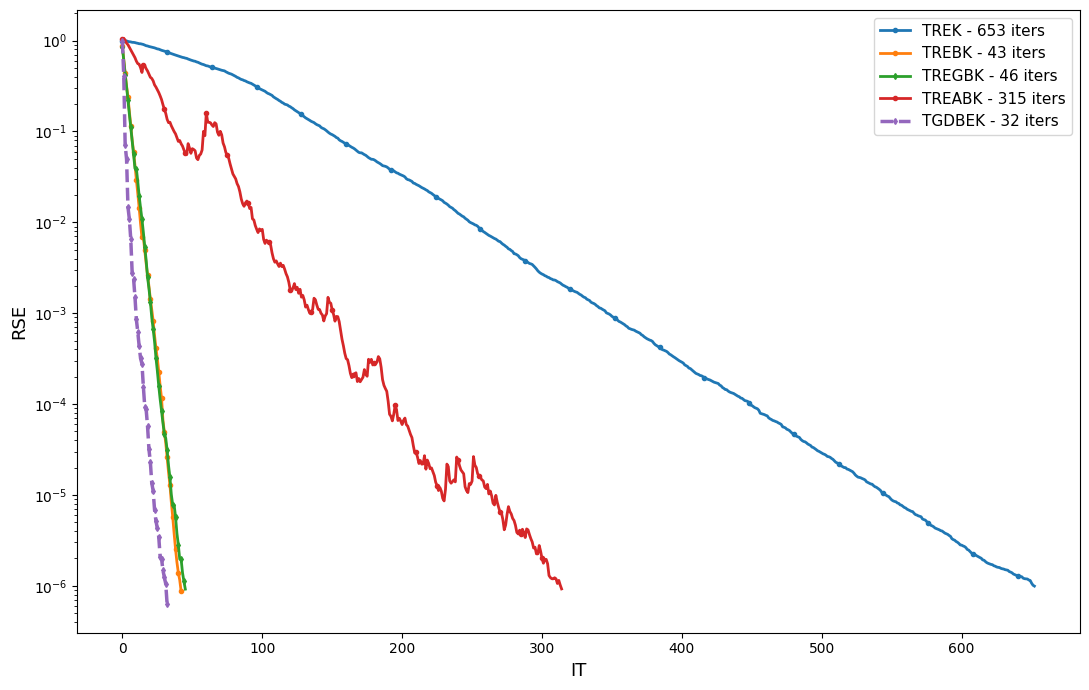

In [52]:
histories = [
  {'name': 'TREK', 'history': hist_trek, 'iterations': k_trek},
  {'name': 'TREBK', 'history': hist_trebk, 'iterations': k_trebk},
  {'name': 'TREGBK', 'history': hist_tregbk, 'iterations': k_tregbk, 'marker': 'd'},
  {'name': 'TREABK', 'history': hist_treabk, 'iterations': k_treabk},
  {'name': 'TGDBEK', 'history': hist_tgdbek, 'iterations': k_tgdbek,
   'linewidth': 2.5, 'linestyle': '--', 'marker': 'd'},
]

plot_convergence(histories)


### 3.3 Benchmark everything: run repeated experiments for different n.

In [16]:

def benchmark_all_tensor_over_n(
    ns=(50, 100, 200, 400, 800),
    m=500,
    p=10,
    q=10,
    noise=0.01,
    tau_row=10,
    tau_col=10,
    max_iter=2000,
    tol=1e-6,
    eta=0.5,          # TGDBEK
    delta=0.7,        # TREGBK
    alpha=12.0,       # TREABK
    n_runs=5,
    seed=1234,
    dtype=torch.float32,
    device=None,
):
    """
    Assumes these are already defined in your notebook:
      - make_tensor_problem(m,n,p,q,noise,seed,dtype,device)  -> (A, X_ls, B)  (as in your usage)
      - make_partitions(n, tau=..., sequential=True)
      - trek_algorithm, trebk_algorithm, tregbk_algorithm, treabk_algorithm, tgdbek_algorithm_faithful
    """
    if device is None:
        device = torch.device("cpu")  # keep CPU-only unless you override

    algos = ["TREK", "TREBK", "TREGBK", "TREABK", "TGDBEK"]

    results_IT  = {a: [] for a in algos}
    results_CPU = {a: [] for a in algos}

    for n in ns:
        print(f"\nBenchmarking n={n} (A: {m}x{n}x{p}, B: {m}x{q}x{p})")

        for algo in algos:
            its_runs = []
            cpu_runs = []

            for r in range(n_runs):
                run_seed = seed + r

                # ----- build the SAME tensor system for all methods (this run) -----
                # Your make_tensor_problem signature may already pick device;
                # we pass device/dtype if your version supports it.
                out = make_tensor_problem(m=m, n=n, p=p, q=q, noise=noise)
                # Your earlier code expects: A, X_ls, B
                A, X_ls, B = out

                # ----- build partitions (only for block methods) -----
                row_parts = make_partitions(m, tau=tau_row, sequential=True)
                col_parts = make_partitions(n, tau=tau_col, sequential=True)

                # ----- run selected method -----
                if algo == "TREK":
                    (X, k_it, hist, xhist), t_cpu = trek_algorithm(
                        A, B, x_ls=X_ls, T=max_iter, tol=tol
                    )

                elif algo == "TREBK":
                    (X, k_it, hist, xhist), t_cpu = trebk_algorithm(
                        A, B, x_ls=X_ls, T=max_iter, tol=tol,
                        row_partitions=row_parts,
                        col_partitions=col_parts
                    )

                elif algo == "TREGBK":
                    (X, k_it, hist, xhist), t_cpu = tregbk_algorithm(
                        A, B, x_ls=X_ls, T=max_iter, delta=delta, tol=tol,
                        row_partitions=row_parts
                    )

                elif algo == "TREABK":
                    # IMPORTANT: match your working call style (you passed only row_partitions)
                    (X, k_it, hist, xhist), t_cpu = treabk_algorithm(
                        A, B, x_ls=X_ls, T=max_iter, alpha=alpha, tol=tol,
                        row_partitions=row_parts
                    )

                elif algo == "TGDBEK":
                    (X, k_it, hist, xhist), t_cpu = tgdbek_algorithm(
                        A, B, T=max_iter, x_ls=X_ls, eta=eta, tol=tol
                    )

                else:
                    raise ValueError(f"Unknown algo: {algo}")

                its_runs.append(float(k_it))
                cpu_runs.append(float(t_cpu))

            results_IT[algo].append(np.mean(its_runs))
            results_CPU[algo].append(np.mean(cpu_runs))

    # -----------------------------
    # Build MultiIndex results table
    # -----------------------------
    index = []
    data = []
    for algo in algos:
        index.append((algo, "IT"))
        data.append(results_IT[algo])
        index.append((algo, "CPU"))
        data.append(results_CPU[algo])

    index = pd.MultiIndex.from_tuples(index, names=["Method", "Metric"])
    cols = [f"{m}x{n}x{p}" for n in ns]
    df = pd.DataFrame(data, index=index, columns=cols).round(3)

    return df

In [17]:
ns = (20, 30, 40, 50, 60, 80)

df_n_sweep = benchmark_all_tensor_over_n(
    ns=ns,
    m=500, p=10, q=10,
    noise=1e-3,
    tau_row=10, tau_col=10,
    max_iter=800, tol=1e-5,
    eta=0.6, delta=0.7, alpha=12.0,
    n_runs=5,
    seed=1234,
    device=torch.device("cpu")
)


Benchmarking n=20 (A: 500x20x10, B: 500x10x10)

Benchmarking n=30 (A: 500x30x10, B: 500x10x10)

Benchmarking n=40 (A: 500x40x10, B: 500x10x10)

Benchmarking n=50 (A: 500x50x10, B: 500x10x10)

Benchmarking n=60 (A: 500x60x10, B: 500x10x10)

Benchmarking n=80 (A: 500x80x10, B: 500x10x10)


In [19]:
df_n_sweep

500x20x10  500x30x10  500x40x10  500x50x10  500x60x10  \
Method Metric                                                          
TREK   IT        547.000    800.000    800.000    800.000    800.000   
       CPU         1.114      1.458      1.569      1.569      1.473   
TREBK  IT         36.000     69.000     97.000    122.000    160.000   
       CPU         0.705      1.415      2.478      2.849      3.760   
TREGBK IT         37.000     63.000     90.000    123.000    151.000   
       CPU         0.580      1.168      1.860      2.707      3.416   
TREABK IT        227.200    145.600    154.400    173.200    201.800   
       CPU         0.511      0.348      0.370      0.327      0.450   
TGDBEK IT         23.000     28.000     33.000     35.000     37.000   
       CPU         0.497      0.652      1.007      1.401      1.460   

               500x80x10  
Method Metric             
TREK   IT        800.000  
       CPU         1.559  
TREBK  IT        247.000  
       CPU         5.835  
TREGBK IT        217.000  
       CPU         5.632  
TREABK IT        260.000  
       CPU         0.494  
TGDBEK IT         44.000  
       CPU         2.385

### 3.3. Sparse overdetermined problem.


 In this example, we use the TGDBEK to solve tensor linear systems $A*X = B+ \epsilon$, where the coefficient tensor  $A$ is a sparse tensor. The sparse tensor $A$ is constructed from the sparse matrix of `numpy` or `pytorch`.

In [54]:
from scipy.sparse import random as sprand


def make_sparse_tensor_system_from_matrix(
    m=1000, n=500, p=10, q=10,
    density=0.01,
    noise=0.01,
    perp_scale=1.0,
    seed=1234,
    device=None,
    dtype=torch.float32,
    rcond=1e-3,
):
    """
    Build an inconsistent tensor system (under t-product):
        B = A * X_true + B_perp + noise

    where A is constructed from a sparse matrix A_mat via :
        A[:,:,0] = A_mat, A[:,:,k]=0 for k>0.

    Returns:
        A      : (m,n,p)
        X_true : (n,q,p)
        B_cons : (m,q,p)
        B      : (m,q,p)
        B_perp : (m,q,p)
        A_mat  : (m,n) dense torch (for debugging)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    rng = np.random.default_rng(seed)


    # 1. Build sparse matrix A_mat in SciPy, convert to torch

    A_sp = sprand(m, n*p, density=density, format="csr",
                  data_rvs=rng.standard_normal, random_state=seed)
    A_mat = A_sp.toarray().astype(np.float32)
    A_mat = torch.from_numpy(A_mat).to(device=device, dtype=dtype)  # (m,n)


    # 2. Embed into tensor A:(m,n,p)

    A = A_mat.reshape(m, n, p).contiguous()          # (m,n,p)

    print("Debug shape of A", A.shape)


    # 3. Generate X_true:(n,q,p)

    # X_true =rng.random(size=(n, q*p))
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    X_true = torch.randn(n, q, p, device=device, dtype=dtype)

    # 4. Consistent RHS: B_cons = A * X_true
    B_cons = t_product(A, X_true)  # (m,q,p)


    # 5) Build B_perp approximately in Null(A^T):

    ii = torch.arange(m, device=device, dtype=dtype).view(m, 1, 1)
    jj = torch.arange(q, device=device, dtype=dtype).view(1, q, 1)
    kk = torch.arange(p, device=device, dtype=dtype).view(1, 1, p)
    R = torch.sin(0.01 * ii) + torch.cos(0.02 * jj) + torch.sin(0.03 * kk)
    print(R.shape)
    Y = t_pinv_apply(A, R, rcond=rcond)          # (n,q,p)
    R_proj = t_product(A, Y)                     # (m,q,p)
    B_perp = R - R_proj                          # (m,q,p)

    print("B_perp:",B_perp.shape)

    # 6. We Add noise
    B = B_cons + B_perp + noise * torch.randn_like(B_cons)

    X_ls = t_pinv_apply(A, B)

    return A, X_ls, B, B_perp

In [61]:
#  Initialize the problem:

noise_level= 0.0; seed=1243; eta = .5

m=150 ; n=1000 ; p = 10 ; q = 10

A_sp, X_sp_ls, B_sp, B_perp  = make_sparse_tensor_system_from_matrix(m, n, p, q)
print("Shape of A", A_sp.shape)
print("density(A_mat) ~", (A_sp != 0).float().mean().item())
# print("||A^T * B_perp|| / ||B_perp|| =", check_null_component(A_sp, B_perp).item())

Debug shape of A torch.Size([150, 1000, 10])
torch.Size([150, 10, 10])
B_perp: torch.Size([150, 10, 10])
Shape of A torch.Size([150, 1000, 10])
density(A_mat) ~ 0.009999999776482582


In [56]:
#  Predfined partitions for TREBK, TREABK, etc.

#  1. Partitions for TREBK. It requires both row and col partitions. # In their papers,
# they used sequential generations with s= number of partitions, and tau = their size.
row_partitions_trebk_sp = make_partitions(m,  tau=10, sequential=True)
col_partitions_trebk_sp = make_partitions(n, tau=10, sequential=True)

#  2. Partitions for TREGBK. It only requires partitioning the rows in s blocks
row_partitions_tregbk_sp = make_partitions(m, tau=10, sequential=True)

#  3. Partitions for TREABK:  The same block partitions style as 1.
row_partitions_treabk_sp = make_partitions(m, tau=10, sequential=True)
col_partitions_treabk_sp = make_partitions(n, tau=10, sequential=True)

print(f"Row and col  partitions TREBK: {(len(row_partitions_treabk_sp), len(col_partitions_trebk_sp))}")
print(f"Row and col  partitions TREGBK: {(len(row_partitions_tregbk_sp), "_ ")}")
print(f"Row and col  partitions TREABK: {(len(row_partitions_treabk_sp), len(col_partitions_treabk_sp))}")

Row and col  partitions TREBK: (15, 100)
Row and col  partitions TREGBK: (15, '_ ')
Row and col  partitions TREABK: (15, 100)


In [62]:
# Run  the experiments
(X_trek_sp, k_trek_sp, hist_trek_sp, x_hist_trek_sp), t_trek_sp = trek_algorithm(A_sp, B_sp,  x_ls=X_sp_ls, T=max_iter, tol=tol)


(X_trebk_sp, k_trebk_sp, hist_trebk_sp, x_hist_trebk_sp), t_trebk_sp = trebk_algorithm(A_sp, B_sp,x_ls =X_sp_ls,T=max_iter, tol=tol,\
                                              row_partitions=row_partitions_trebk_sp, col_partitions=col_partitions_trebk_sp)

(X_tregbk_sp, k_tregbk_sp, hist_tregbk_sp, x_hist_tregbk_sp), t_tregbk_sp  = tregbk_algorithm(A_sp, B_sp, x_ls =X_sp_ls,T=max_iter, delta=0.7, tol=tol, \
                                              row_partitions=row_partitions_tregbk_sp)

# (X_treabk_sp, k_treabk_sp, hist_treabk_sp, x_hist_treabk_sp), t_treabk_sp = treabk_algorithm(A_sp, B_sp, x_ls =X_sp_ls,T=max_iter, alpha=12.0, tol=tol,\
#                                         row_partitions=row_partitions_treabk_sp, col_partitions=col_partitions_treabk_sp)

(X_tgdbek_sp, k_tgdbek_sp, hist_tgdbek_sp, x_hist_tgdbek_sp), t_tgdbek_sp = tgdbek_algorithm(A_sp, B_sp, T=max_iter, x_ls=X_sp_ls,eta=eta, tol=tol, rcond=1e-3)


In [58]:
results = [
    {'name': 'TREK', 'time': t_trek_sp, 'final_residual': hist_trek_sp[-1], 'iterations': k_trek_sp},
    {'name': 'TREBK', 'time': t_trebk_sp, 'final_residual': hist_trebk_sp[-1], 'iterations': k_trebk_sp},
    {'name': 'TREGBK', 'time': t_tregbk_sp, 'final_residual': hist_tregbk_sp[-1], 'iterations': k_tregbk_sp},
    # {'name': 'TREABK', 'time': t_treabk_sp, 'final_residual': hist_treabk_sp[-1], 'iterations': k_treabk_sp},
    {'name': 'TGDBEK', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_sp[-1], 'iterations': k_tgdbek_sp},
  ]

display_results(results)

BENCHMARK RESULTS - TENSOR KACZMARZ METHODS (Using T-Product)
          Method   Time (s)  Final Relative Residual  Iterations
            TREK   4.222055                 0.019263        2000
           TREBK  51.615755                 0.000002        2000
          TREGBK 200.956921                 0.000002        2000
TGDBEK _f (good) 280.316536                 0.000003        2000


,Method,Time (s),Final Relative Residual,Iterations
0,TREK,4.222055,0.019263,2000
1,TREBK,51.615755,0.000002,2000
2,TREGBK,200.956921,0.000002,2000
3,TGDBEK _f (good),280.316536,0.000003,2000


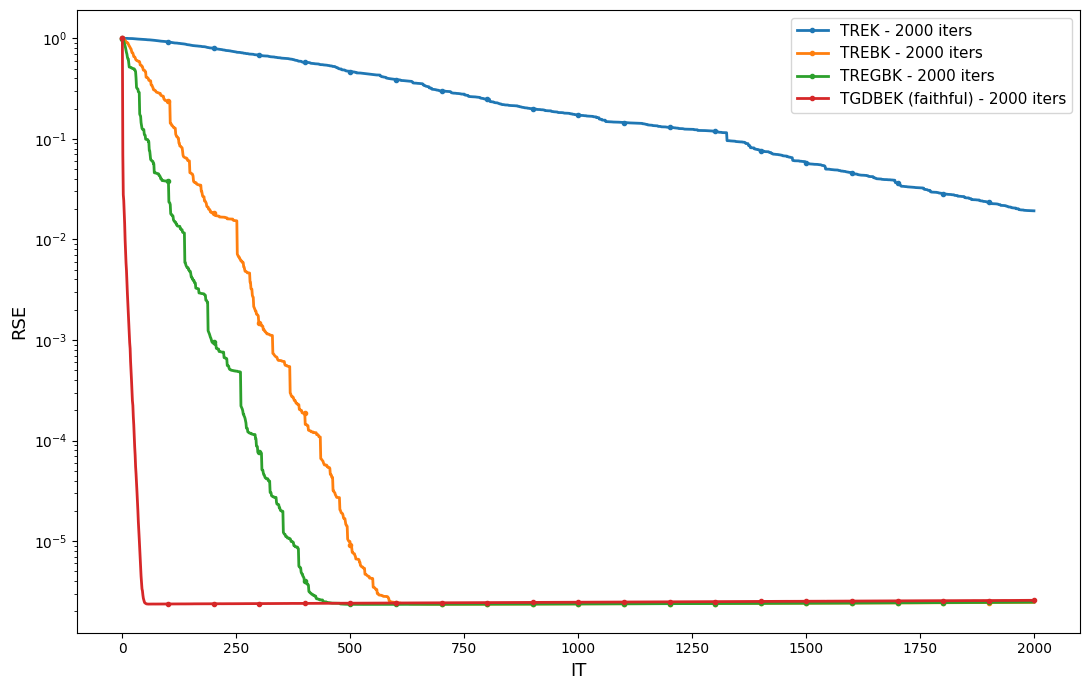

In [63]:
histories = [
  {'name': 'TREK', 'history': hist_trek_sp, 'iterations': k_trek_sp},
  {'name': 'TREBK', 'history': hist_trebk_sp, 'iterations': k_trebk_sp},
  {'name': 'TREGBK', 'history': hist_tregbk_sp, 'iterations': k_tregbk_sp},
  # {'name': 'TREABK', 'history': hist_treabk_sp, 'iterations': k_treabk_sp},
  {'name': 'TGDBEK (faithful)', 'history': hist_tgdbek_sp, 'iterations': k_tgdbek_sp},
  # {'name': 'TGDBEK (random)', 'history': hist_tgdbek_rnd_sp, 'iterations': k_tgdbek_rnd_sp,'linewidth': 2.5, 'linestyle': '--', 'marker': 'd'}
]

plot_convergence(histories)

### 3.4. Dense underdetermined system

In [31]:
# Create test problem

# m, n, p, q = , 500, 10, 10
m, n, p, q = 50, 500,10, 10
noise = 0.1
dtype = torch.float32
eta = 0.5
delta = 0.8
max_iter = 12000
tol = 1e-5

A_d, X_ls_d, B_d = make_tensor_problem(m=m, n=n, p=p, q=q, noise=noise)
print(f"Tensor dimensions: A: {A_d.shape}, B: {B_d.shape}, X: {X_ls_d.shape}")

Tensor dimensions: A: torch.Size([50, 500, 10]), B: torch.Size([50, 10, 10]), X: torch.Size([500, 10, 10])


In [32]:

# Partitions

#  1. Partitions for TREBK. It requires both row and col partitions.

row_partitions_trebk = make_partitions(m, tau=10, sequential=True)
col_partitions_trebk = make_partitions(n, tau=10, sequential=True)

#  2. Partitions for TREGBK. It only requires partitioning the rows in s blocks
row_partitions_tregbk = make_partitions(m, tau=10, sequential=True)

#  3. Partitions for TREABK:  The same block partitions style as 1.
row_partitions_treabk = make_partitions(m, tau=10, sequential=True)
col_partitions_treabk = make_partitions(n,  tau=10, sequential=True)

print(f"Row and col  partitions TREBK: {(len(row_partitions_treabk), len(col_partitions_trebk))}")
print(f"Row and col  partitions TREGBK: {(len(row_partitions_tregbk), "_ ")}")
print(f"Row and col  partitions TREABK: {(len(row_partitions_treabk), len(col_partitions_treabk))}")

Row and col  partitions TREBK: (5, 50)
Row and col  partitions TREGBK: (5, '_ ')
Row and col  partitions TREABK: (5, 50)


In [35]:
# Run  the experiments
(X_trek_d, k_trek_d, hist_trek_d, x_hist_trek_d), t_trek_d = trek_algorithm(A_d, B_d, x_ls=X_ls_d, T=max_iter, tol=tol)


(X_trebk_d, k_trebk_d, hist_trebk_d, x_hist_trebk_d), t_trebk_d = trebk_algorithm(A_d, B_d,x_ls =X_ls_d, T=max_iter, tol=tol,\
                                              row_partitions=row_partitions_trebk, col_partitions=col_partitions_trebk)

(X_tregbk_d, k_tregbk_d, hist_tregbk_d, x_hist_tregbk_d), t_tregbk_d  = tregbk_algorithm(A_d, B_d,x_ls =X_ls_d, T=max_iter, delta=delta, tol=tol, \
                                              row_partitions=row_partitions_tregbk)

# (X_treabk_d, k_treabk_d, hist_treabk_d, x_hist_treabk_d), t_treabk_d = treabk_algorithm(A_d, B_d,x_ls =X_ls_d, T=max_iter, alpha=1.0, tol=tol,\
                                        # row_partitions=row_partitions_treabk)

(X_tgdbek_d, k_tgdbek_d, hist_tgdbek_d, x_hist_tgdbek_d), t_tgdbek_d = tgdbek_algorithm(A_d, B_d,T=max_iter, x_ls=X_ls_d, eta=eta, tol=tol)


In [40]:
results = [
    {'name': 'TREK', 'time': t_trek_d, 'final_residual': hist_trek_d[-1], 'iterations': k_trek_d},
    {'name': 'TREBK', 'time': t_trebk_d, 'final_residual': hist_trebk_d[-1], 'iterations': k_trebk_d},
    {'name': 'TREGBK', 'time': t_tregbk_d, 'final_residual': hist_tregbk_d[-1], 'iterations': k_tregbk_d},
    # {'name': 'TREABK', 'time': t_treabk_d, 'final_residual': hist_treabk_d[-1], 'iterations': k_treabk_d},
    {'name': 'TGDBEK', 'time': t_tgdbek_d, 'final_residual': hist_tgdbek_d[-1], 'iterations': k_tgdbek_d}
  ]

display_results(results)

BENCHMARK RESULTS - TENSOR KACZMARZ METHODS (Using T-Product)
Method  Time (s)  Final Relative Residual  Iterations
  TREK  4.185060                 0.000010        1488
 TREBK  3.066900                 0.000010         122
TREGBK  1.811677                 0.000008          70
TGDBEK  1.221246                 0.000008          28


,Method,Time (s),Final Relative Residual,Iterations
0,TREK,4.185060,0.000010,1488
1,TREBK,3.066900,0.000010,122
2,TREGBK,1.811677,0.000008,70
3,TGDBEK,1.221246,0.000008,28


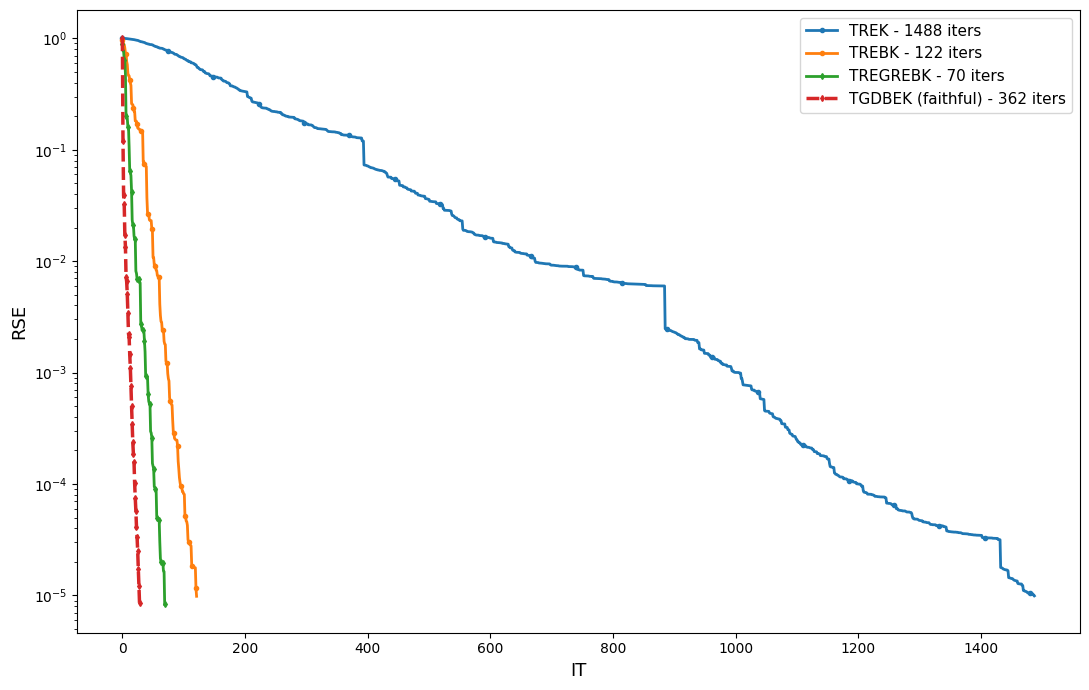

In [37]:
histories = [
  {'name': 'TREK', 'history': hist_trek_d, 'iterations': k_trek_d},
  {'name': 'TREBK', 'history': hist_trebk_d, 'iterations': k_trebk_d},
  {'name': 'TREGREBK', 'history': hist_tregbk_d, 'iterations': k_tregbk_d, 'marker': 'd'},
  # {'name': 'TREABK', 'history': hist_treabk, 'iterations': k_treabk},
  {'name': 'TGDBEK (faithful)', 'history': hist_tgdbek_d, 'iterations': k_tgdbek_f,
   'linewidth': 2.5, 'linestyle': '--', 'marker': 'd'}
]
plot_convergence(histories)